# 03 Classical Graph Analysis
## Centrality, Community Detection & Motif Analysis

### Concepts:
1. **Centrality Measures** PageRank, Betweenness, Closeness, Eigenvector
2. **Community Detection** Louvain modularity optimization
3. **Motif Analysis** Triangles, hubs, structural patterns
4. **Graph-Feature Classification** centrality features Random Forest AUC

### Why This Matters:
Fraud nodes should differ structurally from normal nodes:
- Higher PageRank (suspicious neighborhoods reinforce each other)
- Lower clustering coefficient (radiating star patterns vs dense normal clusters)
- Concentrated in high-fraud communities (fraud rings)


In [3]:
# ============================================================
# Google Colab Setup -- Run this cell FIRST every session
# ============================================================
import os, sys, glob

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ── Roots ────────────────────────────────────────────────────
DRIVE_ROOT   = "/content/drive/MyDrive/fraudDataset"
PROJECT_ROOT = f"{DRIVE_ROOT}/Fraud-Detection-GT"

# Add project src/ to Python path so we can import from src/
sys.path.insert(0, PROJECT_ROOT)

# ── Dataset Paths ─────────────────────────────────────────────
CC_PATH  = f"{DRIVE_ROOT}/creditcard/creditcard.csv"
LEIE_PATH = f"{DRIVE_ROOT}/leie/UPDATED.csv"

# Medicare: 3 separate yearly files (auto-detect names)
MED_DIR = f"{DRIVE_ROOT}/medicare"
MED_FILES = sorted(glob.glob(f"{MED_DIR}/*.csv"))  # finds all CSVs

# ── Output Paths (on Drive  →  survive session restarts) ─────
OUTPUTS_DIR = f"{PROJECT_ROOT}/outputs"
FIGURES_DIR = f"{PROJECT_ROOT}/outputs/figures"
METRICS_DIR = f"{PROJECT_ROOT}/outputs/metrics"
MODELS_DIR  = f"{PROJECT_ROOT}/outputs/models"
GRAPHS_DIR  = f"{PROJECT_ROOT}/data/graphs"

# ML baseline pickles (optional -- upload Fraud-Detection project too)
ML_PICKLES_DIR = f"{DRIVE_ROOT}/Fraud-Detection/pickled_storage"

# Create output directories (idempotent)
for _d in [OUTPUTS_DIR, FIGURES_DIR, METRICS_DIR, MODELS_DIR, GRAPHS_DIR,
           f"{GRAPHS_DIR}/credit_card", f"{GRAPHS_DIR}/medicare"]:
    os.makedirs(_d, exist_ok=True)

# Load config.yaml
import yaml
_cfg_path = f"{PROJECT_ROOT}/config.yaml"
CONFIG = {}
if os.path.exists(_cfg_path):
    with open(_cfg_path) as _f:
        CONFIG = yaml.safe_load(_f)

# ── Status Report ─────────────────────────────────────────────
print("=" * 58)
print("  Fraud Detection GT  |  Colab + Drive Environment")
print("=" * 58)
print(f"  Project Root  : {PROJECT_ROOT}")
print(f"  Credit Card   : {CC_PATH}")
print(f"  LEIE file     : {LEIE_PATH}")
print(f"  Medicare files: {len(MED_FILES)} found in {MED_DIR}")
for _f in MED_FILES:
    print(f"    - {os.path.basename(_f)}")
print()
print(f"  Outputs       : {OUTPUTS_DIR}")
print()

# Verify
_ok = True
for _path, _label in [(CC_PATH, "creditcard/creditcard.csv"),
                       (LEIE_PATH, "leie/UPDATED.csv")]:
    if os.path.exists(_path):
        _mb = os.path.getsize(_path)/1e6
        print(f"  [OK]  {_label} ({_mb:.0f} MB)")
    else:
        print(f"  [!!]  {_label} NOT FOUND")
        _ok = False

if len(MED_FILES) == 0:
    print("  [!!]  No Medicare CSVs found in medicare/")
    _ok = False
elif len(MED_FILES) < 3:
    print(f"  [??]  Only {len(MED_FILES)} Medicare file(s) found (expected 3)")
else:
    total_mb = sum(os.path.getsize(f)/1e6 for f in MED_FILES)
    print(f"  [OK]  medicare/ ({len(MED_FILES)} files, {total_mb:.0f} MB total)")

print()
print("  Ready!" if _ok else "  WARNING: Some files missing -- check Drive paths above")
print("=" * 58)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Fraud Detection GT  |  Colab + Drive Environment
  Project Root  : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT
  Credit Card   : /content/drive/MyDrive/fraudDataset/creditcard/creditcard.csv
  LEIE file     : /content/drive/MyDrive/fraudDataset/leie/UPDATED.csv
  Medicare files: 3 found in /content/drive/MyDrive/fraudDataset/medicare
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2017.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv
    - Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv

  Outputs       : /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs

  [OK]  creditcard/creditcard.csv (151 MB)
  [OK]  leie/UPDATED.csv (15 MB)
  [OK]  medicare/ (3 files, 11921 MB total)

  Ready!


In [4]:
import numpy as np, pandas as pd, networkx as nx
import matplotlib.pyplot as plt, matplotlib, time, json
import warnings; warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.facecolor':'#0F0F1A','axes.facecolor':'#1A1A2E',
    'text.color':'#EEEEFF','axes.labelcolor':'#CCCCEE',
    'xtick.color':'#CCCCEE','ytick.color':'#CCCCEE',
})

from src.graph_builder import load_graph
from src.graph_features import (compute_centrality_features, detect_communities_louvain,
                                  community_fraud_analysis, motif_analysis)
from src.evaluation import compute_metrics

# Load graphs from Drive
G_cc  = load_graph(f'{GRAPHS_DIR}/credit_card/G_cc_knn.pkl')
G_med = load_graph(f'{GRAPHS_DIR}/medicare/G_med_provider.pkl')
print(f"Credit Card: {G_cc.number_of_nodes():,} nodes, {G_cc.number_of_edges():,} edges")
print(f"Medicare:    {G_med.number_of_nodes():,} nodes, {G_med.number_of_edges():,} edges")


Credit Card: 50,000 nodes, 347,127 edges
Medicare:    7,701 nodes, 113,350 edges


## 1. Centrality Analysis

**Degree** — $k(v) = |\mathcal{N}(v)|$ → Fraud hubs have high degree

**PageRank** — $PR(v) = \alpha\sum_{u} \frac{PR(u)}{k(u)}$ → Recursive importance

**Betweenness** — $\frac{\sigma(s,t|v)}{\sigma(s,t)}$ → Broker in fraud ring

**Closeness** — $\frac{n-1}{\sum_u d(v,u)}$ → Distance efficiency

**Eigenvector** — $Ax = \lambda x$ → Connected to well-connected nodes

**Clustering** — $\frac{2t(v)}{k(v)(k(v)-1)}$ → Dense local neighborhood


In [5]:
import time

def compute_centrality_fast(G, name):
    n = G.number_of_nodes()
    print(f"Computing {name} centrality features ({n:,} nodes)...")
    t0 = time.time()

    degree_c    = nx.degree_centrality(G)
    pagerank    = nx.pagerank(G, alpha=0.85, max_iter=200)
    betweenness = nx.betweenness_centrality(G, k=min(n, 300), seed=42)
    clustering  = nx.clustering(G)
    closeness   = nx.closeness_centrality(G) if n <= 10000 else {v: 0.0 for v in G.nodes()}
    try:
        eigenvector = nx.eigenvector_centrality(G, max_iter=300, tol=1e-4)
    except:
        eigenvector = {v: 0.0 for v in G.nodes()}

    records = [{
        "node_id":                node,
        "degree":                 G.degree(node),
        "degree_centrality":      degree_c.get(node, 0),
        "pagerank":               pagerank.get(node, 0),
        "betweenness_centrality": betweenness.get(node, 0),
        "closeness_centrality":   closeness.get(node, 0),
        "eigenvector_centrality": eigenvector.get(node, 0),
        "clustering_coeff":       clustering.get(node, 0),
        "label":                  G.nodes[node].get("label", -1),
    } for node in G.nodes()]

    df = pd.DataFrame(records)
    print(f"  Done in {time.time()-t0:.1f}s | Shape: {df.shape}")
    return df

print("Computing Credit Card centrality features...")
df_cc_cent = compute_centrality_fast(G_cc, "Credit Card")
df_cc_cent.to_csv(f'{METRICS_DIR}/cc_centrality_features.csv', index=False)

print("\nComputing Medicare centrality features...")
df_med_cent = compute_centrality_fast(G_med, "Medicare")
df_med_cent.to_csv(f'{METRICS_DIR}/med_centrality_features.csv', index=False)

print("\nCentrality features saved to Drive")
print(f"  CC  features: {df_cc_cent.shape}")
print(f"  Med features: {df_med_cent.shape}")


Computing Credit Card centrality features...
Computing Credit Card centrality features (50,000 nodes)...
  Done in 100.7s | Shape: (50000, 9)

Computing Medicare centrality features...
Computing Medicare centrality features (7,701 nodes)...
  Done in 45.8s | Shape: (7701, 9)

Centrality features saved to Drive
  CC  features: (50000, 9)
  Med features: (7701, 9)


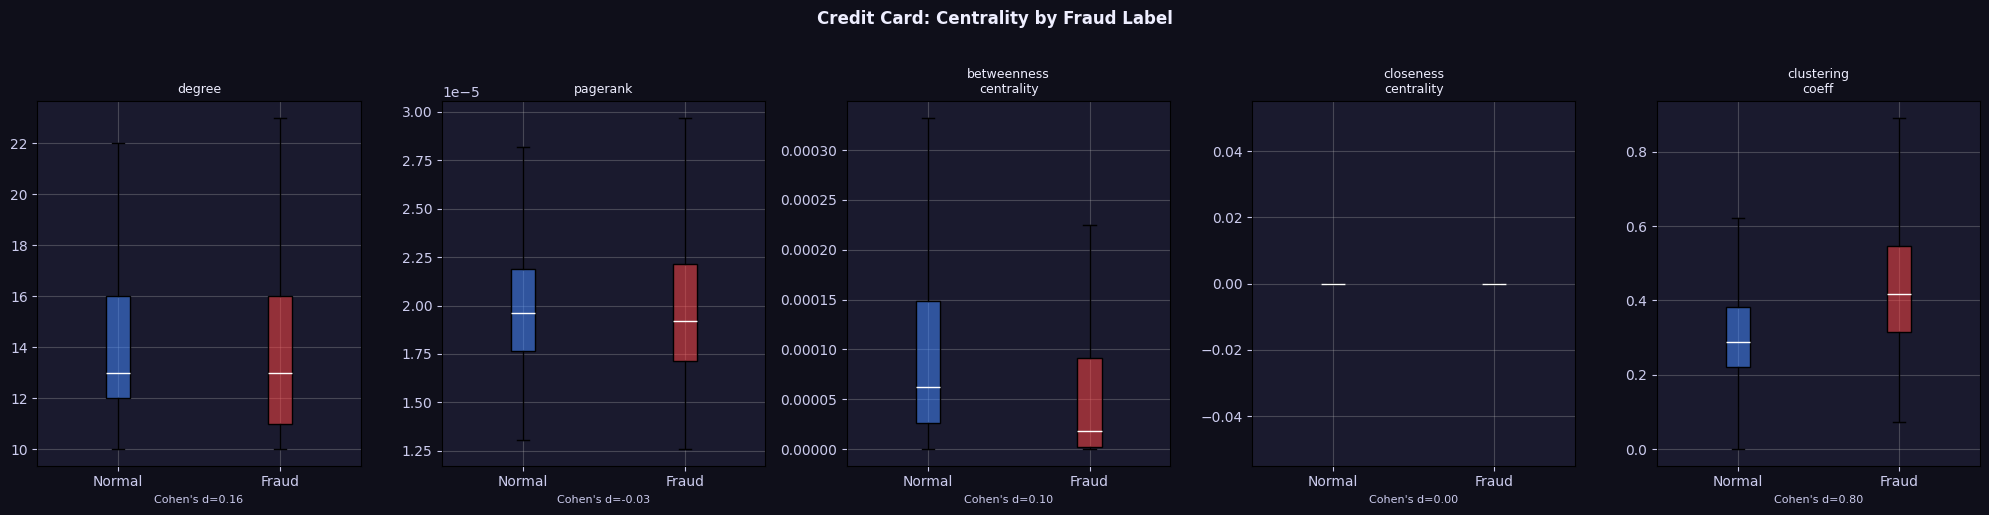

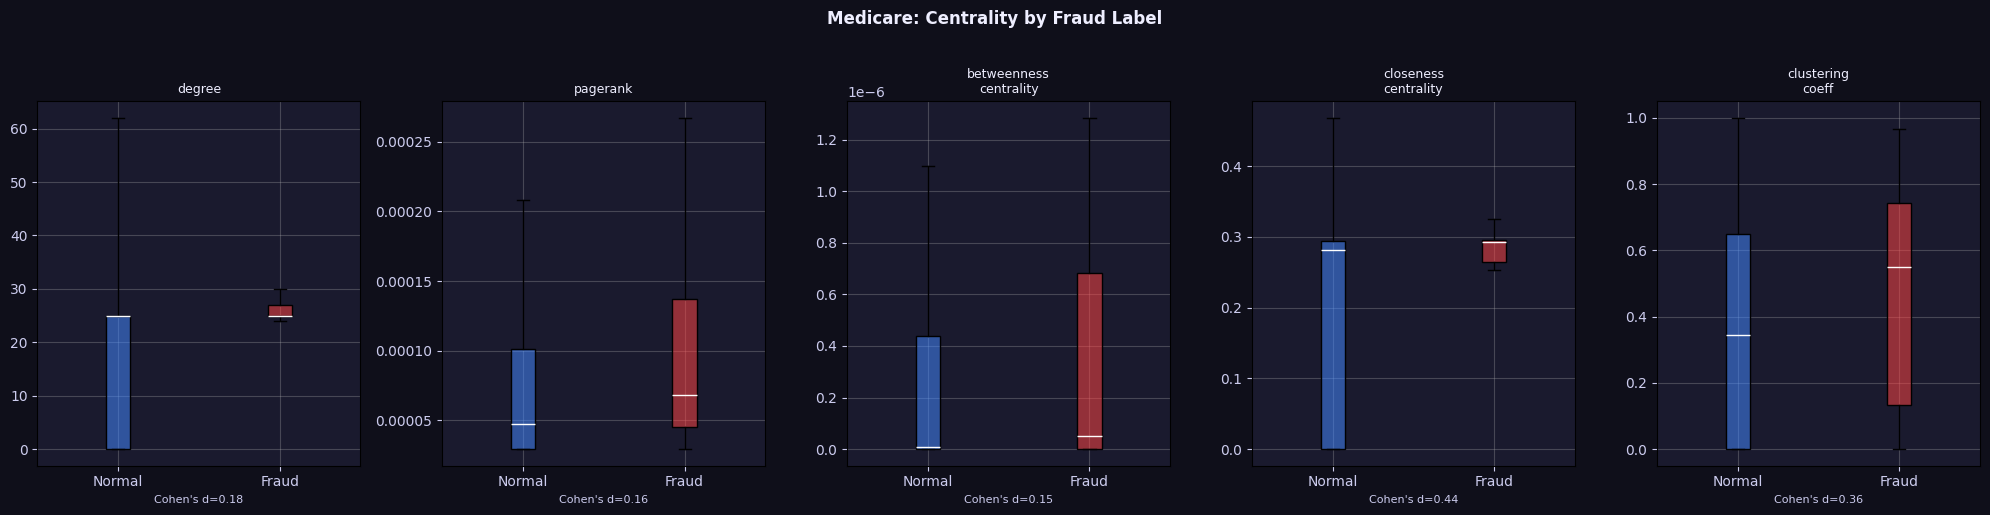

In [6]:
# Centrality comparison plots
def plot_centrality_boxes(df, title, save_path):
    metrics = ['degree','pagerank','betweenness_centrality','closeness_centrality','clustering_coeff']
    metrics = [m for m in metrics if m in df.columns]
    df_v = df[df['label'].isin([0,1])].copy()

    fig, axes = plt.subplots(1, len(metrics), figsize=(4*len(metrics), 5))
    fig.suptitle(title, fontsize=12, color='#EEEEFF', fontweight='bold', y=1.02)

    for ax, m in zip(axes, metrics):
        d_n = df_v[df_v['label']==0][m].values
        d_f = df_v[df_v['label']==1][m].values
        bp = ax.boxplot([d_n, d_f], labels=['Normal','Fraud'],
                         patch_artist=True, showfliers=False)
        bp['boxes'][0].set_facecolor('#4488FF88')
        bp['boxes'][1].set_facecolor('#FF444488')
        for med in bp['medians']: med.set_color('#FFFFFF')
        ax.set_title(m.replace('_','\n'), fontsize=9); ax.grid(True, alpha=0.3)
        if len(d_f)>1:
            ps = np.sqrt((d_f.std()**2+d_n.std()**2)/2)
            d  = (d_f.mean()-d_n.mean())/(ps+1e-10)
            ax.set_xlabel(f"Cohen's d={d:.2f}", fontsize=8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_centrality_boxes(df_cc_cent,  'Credit Card: Centrality by Fraud Label',
                       f'{FIGURES_DIR}/cc_centrality_comparison.png')
plot_centrality_boxes(df_med_cent, 'Medicare: Centrality by Fraud Label',
                       f'{FIGURES_DIR}/med_centrality_comparison.png')


---
## 2. Community Detection Louvain Algorithm

Optimizes **modularity** $Q$:
$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

High $Q$ strong community structure fraud rings appear as dense sub-communities.


In [9]:
# Community detection — using networkx built-in (no python-louvain needed)
from networkx.algorithms.community import louvain_communities, greedy_modularity_communities

def detect_louvain_fixed(G, seed=42):
    try:
        comms = louvain_communities(G, seed=seed)
        partition = {node: cid for cid, comm in enumerate(comms) for node in comm}
        print(f"[Community] Louvain: {len(comms)} communities")
        return partition
    except Exception as e:
        print(f"[Community] Louvain failed ({e}), using greedy modularity...")
        comms = greedy_modularity_communities(G)
        partition = {node: cid for cid, comm in enumerate(comms) for node in comm}
        print(f"[Community] Greedy modularity: {len(comms)} communities")
        return partition

t0 = time.time()
partition_cc = detect_louvain_fixed(G_cc, seed=42)
print(f"Credit Card communities: {len(set(partition_cc.values()))} (in {time.time()-t0:.1f}s)")
comm_cc = community_fraud_analysis(G_cc, partition_cc)
print(comm_cc.head(10).to_string(index=False))


[Community] Louvain: 31 communities
Credit Card communities: 31 (in 11.9s)
 community_id  size  fraud_count  fraud_rate
            0   396          383    0.967172
            1  1069           14    0.013096
           16  3032           30    0.009894
           22   702            5    0.007123
           15  1718            7    0.004075
           28  1837            7    0.003811
           26   859            3    0.003492
           13  2111            7    0.003316
            2  3175           10    0.003150
            4  2457            5    0.002035


In [10]:
t0 = time.time()
partition_med = detect_louvain_fixed(G_med, seed=42)
print(f"Medicare communities: {len(set(partition_med.values()))} (in {time.time()-t0:.1f}s)")
comm_med = community_fraud_analysis(G_med, partition_med)
print(comm_med.head(10).to_string(index=False))


[Community] Louvain: 3042 communities
Medicare communities: 3042 (in 1.3s)
 community_id  size  fraud_count  fraud_rate
         3018     1            1         1.0
         2862     1            1         1.0
          983     1            1         1.0
         1163     1            1         1.0
         2566     1            1         1.0
         2617     1            1         1.0
         1034     1            1         1.0
         1744     1            1         1.0
         1681     1            1         1.0
         1771     1            1         1.0


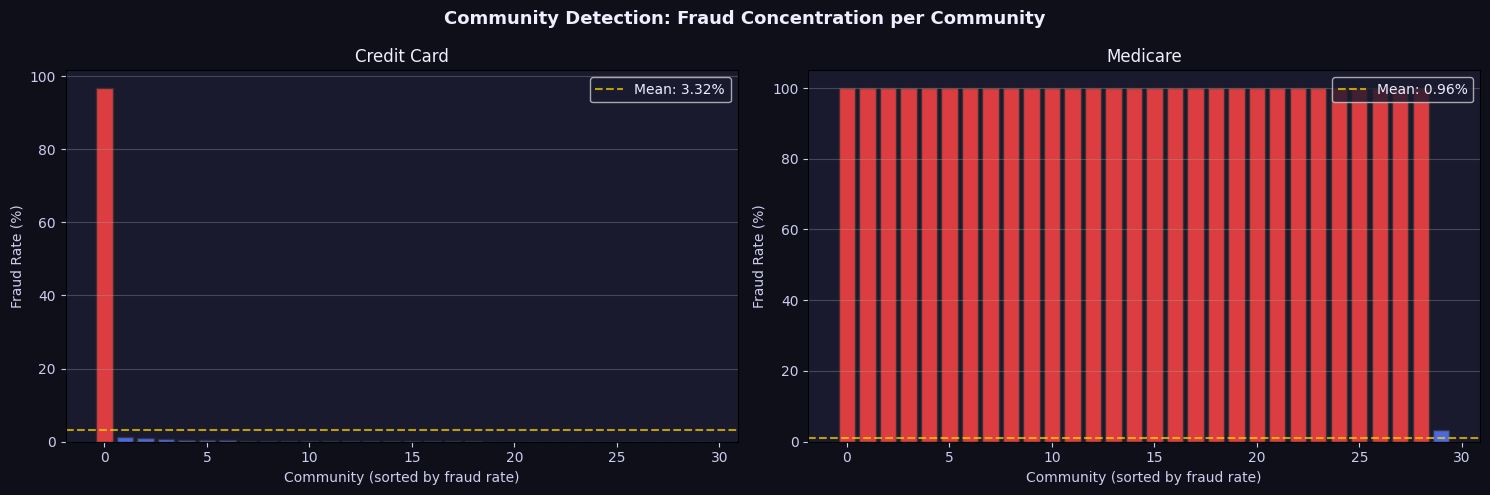

In [11]:
# Community fraud rate visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Community Detection: Fraud Concentration per Community',
              fontsize=13, color='#EEEEFF', fontweight='bold')

for ax, (df_c, title) in zip(axes, [(comm_cc,'Credit Card'), (comm_med,'Medicare')]):
    top = df_c.nlargest(30, 'fraud_rate')
    colors = ['#FF4444' if r > 0.05 else '#5577FF' for r in top['fraud_rate']]
    ax.bar(range(len(top)), top['fraud_rate']*100, color=colors, alpha=0.85, edgecolor='#333')
    mean_r = df_c['fraud_rate'].mean()*100
    ax.axhline(mean_r, color='#FFD700', linestyle='--', alpha=0.7, label=f'Mean: {mean_r:.2f}%')
    ax.set_xlabel('Community (sorted by fraud rate)')
    ax.set_ylabel('Fraud Rate (%)'); ax.set_title(title)
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/community_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 3. Motif Analysis Triangles & Structural Patterns

**Triangles:** A  B  C   
Fraud rings often form complete triads (mutual trust); ghost-billing uses star topologies.

**Hub detection:** Nodes with degree > avg + 2Ïƒ are potential fraud coordinators.


Motif analysis Credit Card...
[Motif] Total triangles: 500,599
[Motif] Hub nodes (degree > avg+2σ): 2543 (55 fraud)

Motif analysis Medicare...
[Motif] Total triangles: 916,963
[Motif] Hub nodes (degree > avg+2σ): 75 (4 fraud)


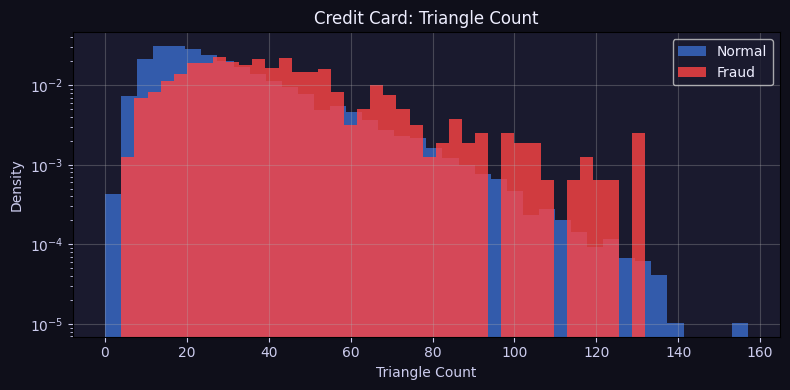

  Mean triangles Fraud: 42.48, Normal: 29.91


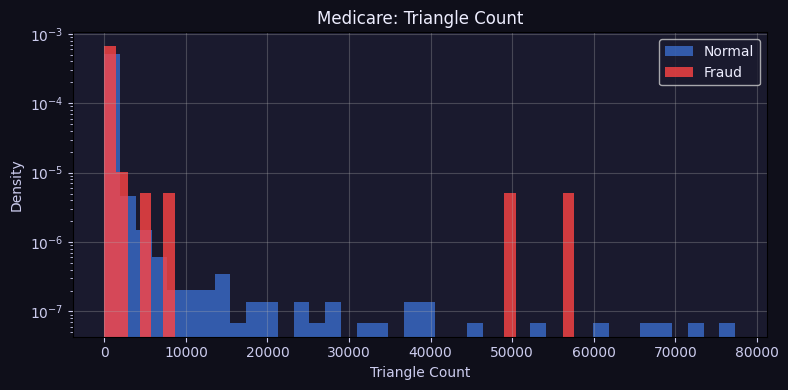

  Mean triangles Fraud: 1082.65, Normal: 344.07


In [12]:
print("Motif analysis Credit Card...")
motif_cc = motif_analysis(G_cc)

print("\nMotif analysis Medicare...")
motif_med = motif_analysis(G_med)

# Triangle count: fraud vs normal
def plot_triangles(G, motif_data, title, save_path):
    tri = motif_data['triangle_per_node']
    f_tri = [tri.get(n,0) for n in G.nodes() if G.nodes[n].get('label')==1]
    n_tri = [tri.get(n,0) for n in G.nodes() if G.nodes[n].get('label')==0]

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(n_tri, bins=40, alpha=0.6, color='#4488FF', label=f'Normal', density=True)
    if f_tri: ax.hist(f_tri, bins=40, alpha=0.8, color='#FF4444', label=f'Fraud', density=True)
    ax.set_title(title, color='#EEEEFF'); ax.set_xlabel('Triangle Count')
    ax.set_ylabel('Density'); ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.show()
    if f_tri:
        print(f"  Mean triangles Fraud: {np.mean(f_tri):.2f}, Normal: {np.mean(n_tri):.2f}")

plot_triangles(G_cc,  motif_cc,  'Credit Card: Triangle Count',
               f'{FIGURES_DIR}/cc_triangles.png')
plot_triangles(G_med, motif_med, 'Medicare: Triangle Count',
               f'{FIGURES_DIR}/med_triangles.png')


---
## 4. Graph-Feature Classification (Category: Graph-Classical)

Use centrality measures as ML features Random Forest AUC on test set.
This gives us the **"Graph-Classical"** row in the final comparison table.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

graph_classical_results = []

def classify_with_centrality(df_cent, dataset_name):
    feat_cols = ['degree','degree_centrality','pagerank','betweenness_centrality',
                 'closeness_centrality','eigenvector_centrality','clustering_coeff']
    feat_cols = [c for c in feat_cols if c in df_cent.columns]
    df_v = df_cent[df_cent['label'].isin([0,1])].dropna(subset=feat_cols)

    if df_v['label'].sum() == 0:
        print(f"  {dataset_name}: No fraud labels skipping")
        return

    X = StandardScaler().fit_transform(df_v[feat_cols].values)
    y = df_v['label'].values
    print(f"\n{dataset_name}: {len(X):,} nodes | {y.sum():,} fraud ({y.mean()*100:.2f}%)")

    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=42, n_jobs=-1)
    scores = cross_val_predict(rf, X, y, cv=5, method='predict_proba')[:,1]
    auc = roc_auc_score(y, scores)
    ap  = average_precision_score(y, scores)
    print(f"  RandomForest on Centrality AUC: {auc:.4f} | AUPRC: {ap:.4f}")

    graph_classical_results.append({
        'dataset': dataset_name, 'category': 'Graph-Classical',
        'method': 'RF_Centrality_Features',
        'auc_roc': auc, 'auc_prc': ap, 'f1': None
    })

classify_with_centrality(df_cc_cent,  'Credit Card')
classify_with_centrality(df_med_cent, 'Medicare')

with open(f'{METRICS_DIR}/classical_graph_results.json', 'w') as f:
    json.dump(graph_classical_results, f, indent=2, default=str)
print("\n Saved to Drive:", f'{METRICS_DIR}/classical_graph_results.json')



Credit Card: 50,000 nodes | 492 fraud (0.98%)
  RandomForest on Centrality AUC: 0.8839 | AUPRC: 0.4431

Medicare: 7,701 nodes | 137 fraud (1.78%)
  RandomForest on Centrality AUC: 0.4332 | AUPRC: 0.0144

 Saved to Drive: /content/drive/MyDrive/fraudDataset/Fraud-Detection-GT/outputs/metrics/classical_graph_results.json


In [14]:
print("=" * 55)
print("  NOTEBOOK 03 COMPLETE")
print("=" * 55)
for r in graph_classical_results:
    print(f"  {r['dataset']:<15} | {r['method']}: AUC={r['auc_roc']:.4f}")
print()
print("  All figures + metrics saved to Drive")
print("  Next 04_Spectral_Methods.ipynb")
print("=" * 55)


  NOTEBOOK 03 COMPLETE
  Credit Card     | RF_Centrality_Features: AUC=0.8839
  Medicare        | RF_Centrality_Features: AUC=0.4332

  All figures + metrics saved to Drive
  Next 04_Spectral_Methods.ipynb
